# Personal Information
Name: **Christos Georghiou**

StudentID: **16072766**

Email: [**christos.georghiou@student.uva.nl**](youremail@student.uva.nl)

Github: [Link](https://github.com/ChrisGeo729/msc-thesis-tiktok-multimodal-classification.git)

Submitted on: **23.03.2026**

# Data Context

This project uses two datasets: TKGO and YouTube-8M-Text. TKGO was accessed via Metabase in collaboration with AI Forensics and contains TikTok videos with associated transcripts and metadata, enabling multimodal analysis of short-form content. YouTube-8M-Text was obtained using publicly available code from the original YouTube-8M authors and extended to include textual features such as titles, descriptions, and tags. It provides a large-scale dataset for text-based video representation.

The two datasets allow comparison between short-form multimodal TikTok data and large-scale text-based YouTube data.

# Data Description

## Imports

In [46]:
import re
import json
import numpy as np
import pandas as pd
import csv
from collections import Counter
import matplotlib.pyplot as plt
from langdetect import detect, LangDetectException
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

## 1. TikTok Global Observatory (TKGO)

### 1.1 Loading the Data

Two versions of the TKGO dataset are loaded:

- **`videos_unique.csv`** — the deduplicated dataset prior to caption enrichment (222,552 unique videos), used as a baseline reference to measure the impact of transcript collection.
- **`query_with_captions_filled.csv`** — the enriched dataset with additional transcripts collected via the pipeline described in section 1.4. This is the working dataset used throughout this analysis.

In addition to captions, thumbnail images have been collected separately for each video and will be transformed into visual feature vectors at a later stage of the thesis. Thumbnail availability is not analyzed here as the visual pipeline is handled independently.

In [5]:
df_tkgo = pd.read_csv("../data/TikTok/videos_unique.csv")
df = pd.read_parquet("/Users/christosgeorghiou/Desktop/MSc Thesis/data/TikTok/tiktok_with_visual_features.parquet")

/var/folders/1n/p856mw397mv8kfjd3gjc5h7h0000gn/T/ipykernel_16277/3689748260.py:1: DtypeWarning: Columns (24,30,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tkgo = pd.read_csv("../data/TikTok/videos_unique.csv")


In [47]:
def is_english(s):
    if not isinstance(s, str) or len(s.strip().split()) < 2:
        return False
    try:
        return detect(s) == "en"
    except Exception:
        return False

In [48]:
df = df[df["num_labels"] > 0].copy()
df["labels_parsed"] = df["Labels_clean"]         
df["desc_clean"] = df["Description"].apply(clean_text)
df = df[df["desc_clean"].apply(is_english)].drop_duplicates(subset="desc_clean")

In [49]:
print(df.shape)

(48664, 47)


In [50]:
print(df.columns)

Index(['Hash', 'Cls', 'AuthorFollowers', 'AuthorFollowing', 'AuthorId',
       'AuthorName', 'AuthorProfileLikes', 'AuthorVideoLikes', 'AuthorVideos',
       'Captions', 'Comments', 'CountryCode', 'CreateTime', 'Creation Date',
       'CurlId', 'CurlTime', 'Description', 'Duration', 'Labels', 'Likes',
       'Modified Date', 'MusicAuthor', 'MusicDuration', 'MusicId',
       'MusicOriginal', 'MusicTitle', 'Nickname', 'Order', 'Schema Version',
       'Shares', 'VideoId', 'Views', 'Caption Attempts', 'DiversificationId',
       'State Code', 'HtmlEvidence', 'rgb_l2', 'rgb_mean', 'rgb_std',
       'embedding', 'Labels_clean', 'num_labels', 'label_depth',
       'caption_words', 'hashtags', 'labels_parsed', 'desc_clean'],
      dtype='object')


In [51]:
print(df.dtypes)

Hash                   object
Cls                    object
AuthorFollowers       float64
AuthorFollowing       float64
AuthorId              float64
AuthorName             object
AuthorProfileLikes    float64
AuthorVideoLikes      float64
AuthorVideos          float64
Captions               object
Comments              float64
CountryCode            object
CreateTime             object
Creation Date          object
CurlId                 object
CurlTime               object
Description            object
Duration              float64
Labels                 object
Likes                 float64
Modified Date          object
MusicAuthor            object
MusicDuration         float64
MusicId               float64
MusicOriginal            bool
MusicTitle             object
Nickname               object
Order                   int64
Schema Version          int64
Shares                float64
VideoId                 int64
Views                 float64
Caption Attempts        int64
Diversific

In [52]:
df.head()

,Hash,Cls,AuthorFollowers,AuthorFollowing,AuthorId,AuthorName,AuthorProfileLikes,AuthorVideoLikes,AuthorVideos,Captions,...,rgb_mean,rgb_std,embedding,Labels_clean,num_labels,label_depth,caption_words,hashtags,labels_parsed,desc_clean
0,0ac81d22e256d827dd6d9cc204956ba6950a0d31,TKGlobalForYouVideo,49000.0,0.0,7.092874e+18,yourlocaldq1,26.0,542000.0,60.0,None,...,NaN,NaN,None,"[Drinks, Food & Drink, Lifestyle]",3,3,NaN,ready set lift dq dance with turbotax quaker p...,"[Drinks, Food & Drink, Lifestyle]",oreo milkshake readysetlift dq dancewithturbot...
1,c84383be1fe9dd44ebb54a5b3fecf0e60950e5f2,TKGlobalForYouVideo,1400000.0,59.0,1.316130e+07,serene.hesri,5063.0,27500000.0,231.0,"WEBVTT 00:00:00.042 --> 00:00:01.681 Hey, guys...",...,-0.023647,0.653779,"[-0.2590745985507965, 0.16874973475933075, -0....","[Cooking, Food & Drink, Lifestyle]",3,3,627.0,late night snack tuna capers tuna ca do foodie,"[Cooking, Food & Drink, Lifestyle]",capers are the immature unripened green flower...
2,bf60a6a140a156a806c52bc4dc3a23e25154f9ba,TKGlobalForYouVideo,633200.0,737.0,6.950711e+18,qwertykey.ro,1725.0,35100000.0,1828.0,WEBVTT 00:00:00.000 --> 00:00:04.000 How is a ...,...,0.004796,0.699168,"[0.04119686782360077, -0.6245220899581909, -0....","[Tech Products & Infos, Technology, Culture & ...",3,3,24.0,qwerty key qwerty apple screen protector apple...,"[Tech Products & Infos, Technology, Culture & ...",it looks like a surgery qwertykey qwerty apple...
3,e9cf64db6e55d0859b4c1735853ee51d61fc4ed7,TKGlobalForYouVideo,14400000.0,1428.0,6.740961e+18,mdmotivator,9576.0,593900000.0,1708.0,WEBVTT 00:00:01.436 --> 00:00:04.675 I wish. H...,...,0.002780,0.672075,"[0.13048000633716583, -1.149530291557312, 0.33...","[Street Interviews & Social Experiments, Socie...",3,3,400.0,lucky travel warm money pay it forward kindnes...,"[Street Interviews & Social Experiments, Socie...",i m having a bad day donation l1nk l1ve lucky ...
4,77b9e757a55ee63e5dd3c844e1cda12cfb001320,TKGlobalForYouVideo,23200000.0,492.0,7.835848e+06,jeremylynch,12700.0,487300000.0,916.0,WEBVTT 00:00:00.055 --> 00:00:03.863 Hi. Hey. ...,...,-0.006589,0.645061,"[0.3479723334312439, -0.7760737538337708, 0.31...","[Scripted Comedy, Comedy, Performance]",3,3,354.0,,"[Scripted Comedy, Comedy, Performance]",when you order at the coffee shop watch until ...


### 1.2 Corpus Overview

The deduplicated TKGO dataset contains **222,552 unique videos** across **36 features**, 
combining engagement metrics, author metadata, textual fields, and categorical labels. 
Note that the raw crawl contains 1,000,000 rows, since the same video can appear multiple times as it was served to different For You feeds during data collection. 
After deduplication by `VideoId`, 222,552 unique videos remain.

The table below shows missing value rates across all columns. Key observations:
- `Captions` is the primary textual feature but has significant missingness, motivating the transcript collection pipeline described in section 1.4.
- `HtmlEvidence`, `State Code`, and `DiversificationId` have high missingness and are not relevant to this study.
- Core engagement metrics (`Views`, `Likes`, `Comments`, `Shares`) are largely complete.

In [53]:
# Missing values summary
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Dtype": df.dtypes
}).sort_values("Missing %", ascending=False)

missing.style.background_gradient(subset=["Missing %"], cmap="Reds")

,Missing Count,Missing %,Dtype
DiversificationId,48664,100.000000,float64
State Code,46570,95.700000,object
caption_words,33986,69.840000,float64
Captions,33986,69.840000,object
HtmlEvidence,22387,46.000000,object
rgb_mean,15002,30.830000,float64
rgb_l2,15002,30.830000,float64
embedding,15002,30.830000,object
rgb_std,15002,30.830000,float64
CountryCode,218,0.450000,object


### 1.3 Label Analysis

The `Labels` column is stored as a string representation of a list rather than a proper Python list. 
Labels are parsed using a regex extractor to produce a clean list per video.

In [54]:
def clean_labels(label):
    if pd.isna(label):
        return []
    return re.findall(r'"([^"]*)"', label)

df["Labels_clean"] = df["Labels"].apply(clean_labels)

In [55]:
df["Labels_clean"].head()

0                    [Drinks, Food & Drink, Lifestyle]
1                   [Cooking, Food & Drink, Lifestyle]
2    [Tech Products & Infos, Technology, Culture & ...
3    [Street Interviews & Social Experiments, Socie...
4               [Scripted Comedy, Comedy, Performance]
Name: Labels_clean, dtype: object

In [56]:
all_labels = [label for sublist in df["Labels_clean"] for label in sublist]

label_counts = Counter(all_labels)

In [57]:
len(set(all_labels))

101

In [58]:
df["num_labels"] = df["Labels_clean"].apply(len)
df["num_labels"].describe()

count    48664.000000
mean         2.843807
std          0.378885
min          1.000000
25%          3.000000
50%          3.000000
75%          3.000000
max          3.000000
Name: num_labels, dtype: float64

In [59]:
label_df = pd.DataFrame(label_counts.items(), columns=["Label", "Count"])
label_df = label_df.sort_values(by="Count", ascending=False)

label_df.head(10)

,Label,Count
11,Performance,10342
31,Entertainment,9573
2,Lifestyle,7516
10,Comedy,6844
30,Entertainment Culture,5971
24,Lip-sync,5762
14,Talents,4268
16,Daily Life,3952
8,Society,3634
23,Sport & Outdoor,3595


#### Label Coverage and Depth

65.69% of videos have at least one label assigned. Most labeled videos carry exactly 3 labels, 
which reflects TikTok's hierarchical tagging system where labels are assigned at multiple levels of granularity.

In [60]:
total = len(df)
with_labels = df["Labels_clean"].apply(len).gt(0).sum()

print(f"Total instances: {total}")
print(f"With labels: {with_labels}")
print(f"Coverage: {with_labels / total:.2%}")

Total instances: 48664
With labels: 48664
Coverage: 100.00%


In [61]:
df["label_depth"] = df["Labels_clean"].apply(len)
df["label_depth"].value_counts()


label_depth
3    41349
2     7029
1      286
Name: count, dtype: int64

#### Full Label Distribution (Top 30)

The label space consists of 101 unique labels with a heavily skewed distribution. 
Performance, Lip-sync, and Entertainment dominate, reflecting the nature of TikTok as an entertainment platform. 
This imbalance is important, since rare labels will be harder to predict and the naive baseline will be driven by the top label.

In [62]:
labels_exploded = (
    df["Labels_clean"]
    .explode()
    .dropna()
)

label_counts = labels_exploded.value_counts()

print("Unique labels:", label_counts.shape[0])
print(label_counts.head(30))


Unique labels: 101
Labels_clean
Performance                         10342
Entertainment                        9573
Lifestyle                            7516
Comedy                               6844
Entertainment Culture                5971
Lip-sync                             5762
Talents                              4268
Daily Life                           3952
Society                              3634
Sport & Outdoor                      3595
Beauty & Style                       3541
Singing & Dancing                    3480
Food & Drink                         3210
Outfit                               2868
Sports                               2851
Movies & TV works                    2684
Traditional Sports                   2404
Celebrity Clips & Variety Show       2200
Games                                2175
Others                               2126
Random Shoot                         2085
Beauty & Care                        1999
Scripted Comedy                      1907
Co

### 1.4 Caption Enrichment

Captions represent the primary textual feature for TKGO, capturing the spoken content of each video. 
The raw deduplicated dataset has significant caption missingness. To address this, a two-strategy transcript collection pipeline was applied:

1. **subtitleInfos**: native TikTok subtitles extracted directly from the page JSON (higher quality as they are human-verified or auto-generated by TikTok).
2. **Whisper**: OpenAI Whisper base model transcription as a fallback when no native subtitles were available (lower quality but extends coverage to videos without native subtitles).

The coverage table and source breakdown below show the impact of enrichment. The language comparison reveals whether the newly collected transcripts follow the same language distribution as the original captions.

In [38]:
def valid_caption_mask(series):
    return (
        series.notna() &
        (series.astype(str).str.strip() != "") &
        (series.astype(str).str.lower().str.strip() != "nan")
    )

valid_cap_before = valid_caption_mask(df_tkgo["Captions"])
valid_cap_after  = valid_caption_mask(df["Captions"])

print("Caption Coverage:")
print(f"{'':35s} {'Count':>8} {'Coverage':>10}")
print(f"{'Before enrichment (videos_unique)':35s} {valid_cap_before.sum():>8,} {valid_cap_before.mean():>10.2%}")
print(f"{'After enrichment (captions_filled)':35s} {valid_cap_after.sum():>8,} {valid_cap_after.mean():>10.2%}")
print(f"{'Newly added':35s} {valid_cap_after.sum()-valid_cap_before.sum():>8,}")

Caption Coverage:
                                       Count   Coverage
Before enrichment (videos_unique)     34,036     15.29%
After enrichment (captions_filled)   165,536     74.89%
Newly added                          131,500


In [21]:
import os
from pathlib import Path

vtt_root = Path("../data/TikTok/tiktok_transcripts_out")

whisper_count = 0
subtitle_count = 0

for vtt_path in vtt_root.rglob("*.vtt"):
    if "_whisper_" in vtt_path.name:
        whisper_count += 1
    else:
        subtitle_count += 1

total_collected = whisper_count + subtitle_count
print(f"Total VTT files collected : {total_collected:,}")
print(f"  via subtitle API        : {subtitle_count:,}")
print(f"  via Whisper fallback    : {whisper_count:,}")

Total VTT files collected : 11,268
  via subtitle API        : 1,743
  via Whisper fallback    : 9,525


In [22]:
def detect_lang(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return "unknown"
    
# Which videos are newly captioned
newly_captioned_mask = valid_cap_after & ~valid_caption_mask(df_tkgo["Captions"])

df_captions_orig = df[valid_caption_mask(df_tkgo["Captions"])].copy()
df_captions_new  = df[newly_captioned_mask].copy()

df_captions_orig["lang"] = df_captions_orig["Captions"].apply(detect_lang)
df_captions_new["lang"]  = df_captions_new["Captions"].apply(detect_lang)

lang_orig = df_captions_orig["lang"].value_counts().head(10).rename("Original")
lang_new  = df_captions_new["lang"].value_counts().head(10).rename("Newly Added")
pd.concat([lang_orig, lang_new], axis=1).fillna(0).astype(int)

/var/folders/1n/p856mw397mv8kfjd3gjc5h7h0000gn/T/ipykernel_16277/491971228.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_captions_orig = df[valid_caption_mask(df_tkgo["Captions"])].copy()
/var/folders/1n/p856mw397mv8kfjd3gjc5h7h0000gn/T/ipykernel_16277/491971228.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_captions_new  = df[newly_captioned_mask].copy()


,Original,Newly Added
lang,,
en,26962,134415
no,6110,0
it,173,0
so,54,335
pt,53,229
id,46,269
tl,39,246
es,29,205
cy,24,0


### 1.5 Caption Text Analysis

The following analysis covers the linguistic properties of the enriched caption corpus. 
Since captions originate from three different sources (original TKGO, native subtitleInfos, and Whisper), 
the vocabulary statistics reflect a mix of transcription styles. 
Whisper transcripts in particular tend to lack punctuation and may introduce noise through hallucinated words on non-speech segments. 
Captions under 5 words are treated as noise and are excluded during preprocessing.

<Axes: xlabel='caption_words', ylabel='Count'>

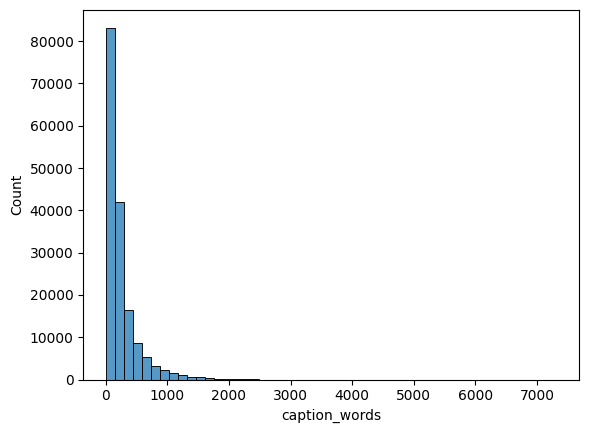

In [23]:
import seaborn as sns

df["caption_words"] = df["Captions"].str.split().str.len()
df["caption_words"].describe()

sns.histplot(df["caption_words"], bins=50)

In [24]:
# How many are under 5 words 
(df["caption_words"] < 5).sum()

1059

In [25]:
all_words = " ".join(df["Captions"].dropna()).lower().split()
vocab = Counter(all_words)
hapax = sum(1 for w, c in vocab.items() if c == 1)
print(f"Vocabulary size: {len(vocab):,}")
print(f"Words used only once: {hapax:,} ({hapax/len(vocab):.1%} of vocab)")

Vocabulary size: 424,213
Words used only once: 194,402 (45.8% of vocab)


In [28]:
from collections import Counter
from wordsegment import load, segment
load()

def extract_hashtags(text):
    if not isinstance(text, str):
        return ""
    tags = re.findall(r"#(\w+)", text)
    return " ".join(" ".join(segment(t)) for t in tags)

df["hashtags"] = df["Description"].apply(extract_hashtags)

text_cols = {
    "Descriptions": "Description",
    "Captions": "Captions",
    "Hashtags": "hashtags",
}

In [29]:
rows = []
for name, col in text_cols.items():
    s = df[col].dropna().astype(str)
    s = s[s.str.strip() != ""]
    wc = s.str.split().str.len()

    all_words = " ".join(s).lower().split()
    vocab = Counter(all_words)
    hapax = sum(1 for w, c in vocab.items() if c == 1)

    rows.append({
        "Source": name,
        "Non-empty docs": len(s),
        "Median words": wc.median(),
        "Mean words": round(wc.mean(), 1),
        "Docs < 5 words": int((wc < 5).sum()),
        "Vocab size": len(vocab),
        "Hapax": hapax,
        "Hapax %": round(hapax / len(vocab) * 100, 1) if len(vocab) else 0,
    })

summary = pd.DataFrame(rows).set_index("Source")
summary

,Non-empty docs,Median words,Mean words,Docs < 5 words,Vocab size,Hapax,Hapax %
Source,,,,,,,
Descriptions,212465,10.0,13.8,32888,566366,352761,62.3
Captions,165536,145.0,230.3,1057,424213,194402,45.8
Hashtags,166879,9.0,11.7,38039,71945,24495,34.0


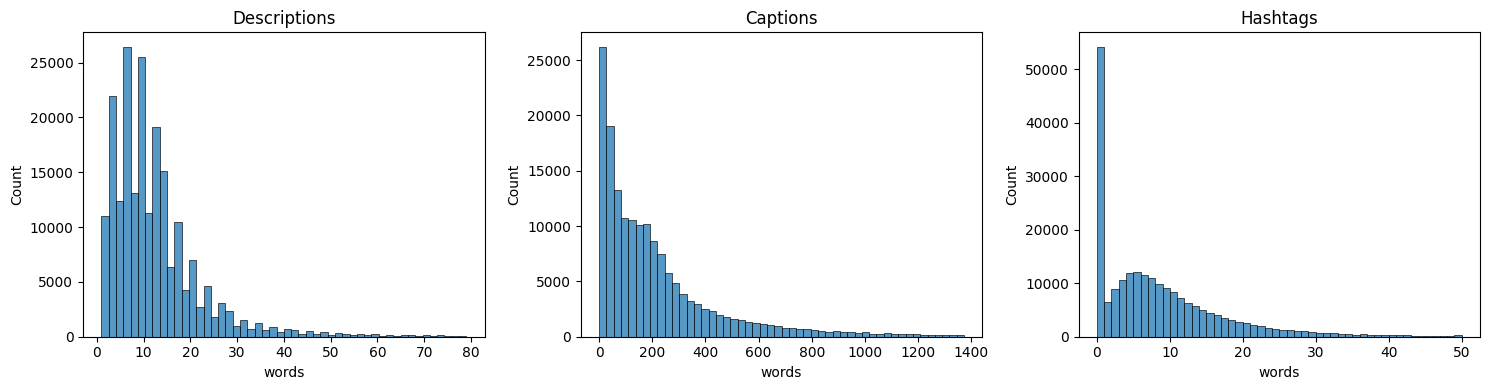

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, col) in zip(axes, text_cols.items()):
    wc = df[col].dropna().astype(str).str.split().str.len()
    sns.histplot(wc[wc <= wc.quantile(0.99)], bins=50, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("words")
plt.tight_layout()

### 1.6 Label Distribution

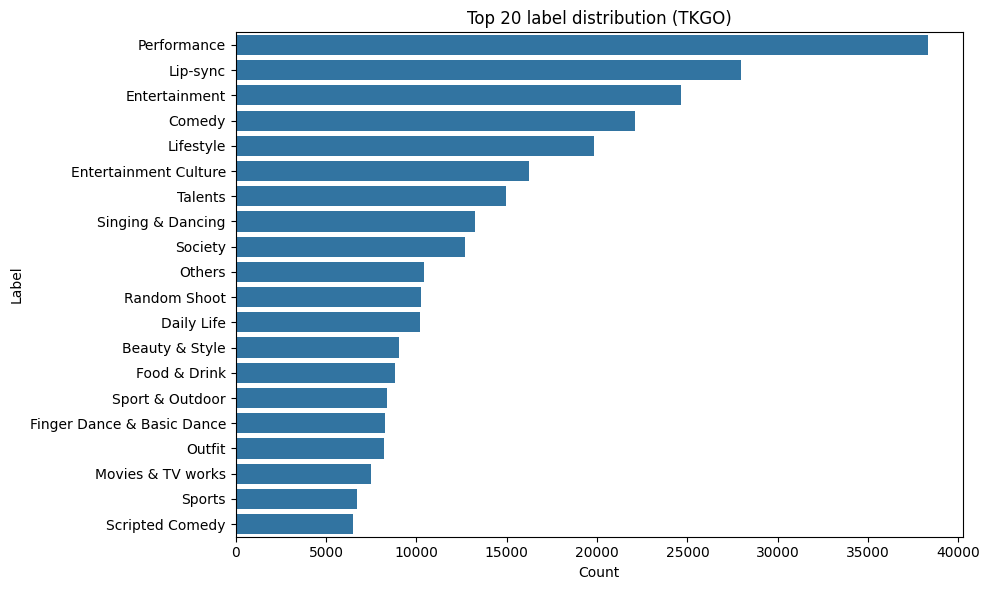

In [28]:
top_labels = label_df.head(20)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_labels, x="Count", y="Label")
plt.title("Top 20 label distribution (TKGO)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

### 1.7 Caption Representativeness

A key question for this study is whether videos with captions are representative of the full dataset. 
If captioned videos cluster in specific content categories, any model trained on them may not generalise well to the full label space. 
The chart below compares the normalised label distribution of captioned vs non-captioned videos. 
Significant divergence between the two distributions would indicate selection bias introduced by caption availability.

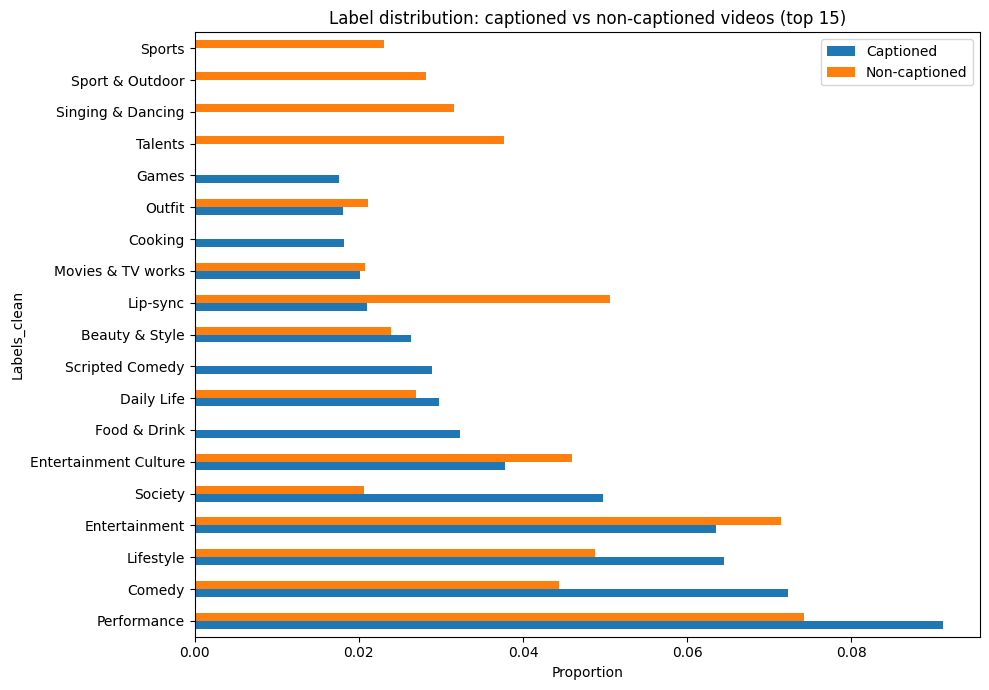

                       Captioned  Non-captioned
Labels_clean                                   
Performance                0.091          0.074
Comedy                     0.072          0.044
Lifestyle                  0.064          0.049
Entertainment              0.063          0.071
Society                    0.050          0.021
Entertainment Culture      0.038          0.046
Food & Drink               0.032          0.000
Daily Life                 0.030          0.027
Scripted Comedy            0.029          0.000
Beauty & Style             0.026          0.024
Lip-sync                   0.021          0.051
Movies & TV works          0.020          0.021
Cooking                    0.018          0.000
Outfit                     0.018          0.021
Games                      0.018          0.000
Talents                    0.000          0.038
Singing & Dancing          0.000          0.032
Sport & Outdoor            0.000          0.028
Sports                     0.000        

In [40]:
valid_cap = valid_caption_mask(df["Captions"])

captioned_labels = (
    df[valid_cap]["Labels_clean"]
    .explode().dropna()
    .loc[lambda x: x != ""]
    .value_counts(normalize=True)
    .head(15)
    .rename("Captioned")
)

non_captioned_labels = (
    df[~valid_cap]["Labels_clean"]
    .explode().dropna()
    .loc[lambda x: x != ""]
    .value_counts(normalize=True)
    .head(15)
    .rename("Non-captioned")
)

comparison = pd.concat([captioned_labels, non_captioned_labels], axis=1).fillna(0)
comparison.plot(kind="barh", figsize=(10, 7))
plt.title("Label distribution: captioned vs non-captioned videos (top 15)")
plt.xlabel("Proportion")
plt.tight_layout()
plt.show()

print(comparison.round(3))

### 1.8 TF-IDF Baseline

To establish a meaningful baseline, a TF-IDF + Logistic Regression classifier is trained on the enriched TKGO captions. 
This mirrors the approach used for YouTube-8M-Text and provides a concrete micro-F1 and macro-F1 score that any subsequent model must exceed. 
Only videos with at least one label and a caption of at least 2 tokens after cleaning are included.

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score
import re

def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"(https?://\S+|www\.\S+)", "", s)
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

# Prepare TKGO — captioned videos with at least one label
df_tkgo_model = df[valid_cap & df["Labels_clean"].apply(len).gt(0)].copy()
df_tkgo_model["text"] = df_tkgo_model["Captions"].apply(clean_text)
df_tkgo_model = df_tkgo_model[
    df_tkgo_model["text"].str.split().apply(len) >= 2
].reset_index(drop=True)

print(f"Model-ready videos : {len(df_tkgo_model):,}")
print(f"Dropped (too short): {df[valid_cap & df['Labels_clean'].apply(len).gt(0)].shape[0] - len(df_tkgo_model):,}")
print(f"Label space        : {df_tkgo_model['Labels_clean'].explode().nunique()} unique labels")

mlb_tkgo = MultiLabelBinarizer()
Y_tkgo = mlb_tkgo.fit_transform(df_tkgo_model["Labels_clean"])
X_tkgo = df_tkgo_model["text"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X_tkgo, Y_tkgo, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train):,}  Test: {len(X_test):,}")

Model-ready videos : 58,862
Dropped (too short): 221
Label space        : 99 unique labels

Train: 47,089  Test: 11,773


In [42]:
model_tkgo = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
    ))
])

model_tkgo.fit(X_train, Y_train)
Y_prob_tkgo = model_tkgo.predict_proba(X_test)

best_tkgo = None
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    Y_pred = (Y_prob_tkgo >= t).astype(int)
    f1 = f1_score(Y_test, Y_pred, average="micro", zero_division=0)
    if best_tkgo is None or f1 > best_tkgo[1]:
        best_tkgo = (t, f1)

Y_pred_tkgo = (Y_prob_tkgo >= best_tkgo[0]).astype(int)

print("TF-IDF Baseline (TKGO Captions): ")
print(f"Best threshold : {best_tkgo[0]}")
print(f"Micro Precision: {precision_score(Y_test, Y_pred_tkgo, average='micro', zero_division=0):.4f}")
print(f"Micro Recall   : {recall_score(Y_test, Y_pred_tkgo, average='micro', zero_division=0):.4f}")
print(f"Micro F1       : {f1_score(Y_test, Y_pred_tkgo, average='micro', zero_division=0):.4f}")
print(f"Macro F1       : {f1_score(Y_test, Y_pred_tkgo, average='macro', zero_division=0):.4f}")

TF-IDF Baseline (TKGO Captions): 
Best threshold : 0.5
Micro Precision: 0.3583
Micro Recall   : 0.7918
Micro F1       : 0.4934
Macro F1       : 0.4380


## 2. YouTube-8M-Text

In [31]:
df_yt = pd.read_parquet("../data/Youtube/yt8m_metadata.parquet")

print(f"Shape: {df_yt.shape}")
print(f"Columns: {list(df_yt.columns)}")

Shape: (4606350, 6)
Columns: ['yt8m_id', 'YouTube_id', 'label_names_json', 'title', 'tags_json', 'status']


### 2.1 Corpus Overview

The YouTube-8M-Text dataset contains **225,042 videos** with multi-label annotations and textual metadata. 
Unlike TKGO where the primary text feature is spoken captions (with limited coverage), 
YouTube-8M-Text relies on video **titles** and **tags** as textual features, which are available for the majority of videos (84–90%). 
This makes it a higher-coverage but metadata-based alternative to caption-driven text features.

The missing values table below shows that `mean_rgb_json` and `mean_audio_json` contain pre-extracted audio-visual features from the original YouTube-8M dataset. 
These are not used in this thesis, which focuses on the textual features.

In [33]:
missing_yt = pd.DataFrame({
    "Missing Count": df_yt.isnull().sum(),
    "Missing %": (df_yt.isnull().sum() / len(df_yt) * 100).round(2),
    "Dtype": df_yt.dtypes
}).sort_values("Missing %", ascending=False)

missing_yt.style.background_gradient(subset=["Missing %"], cmap="Reds")

,Missing Count,Missing %,Dtype
title,34963,15.540000,object
channelTitle,34963,15.540000,object
publishedAt,34963,15.540000,object
YouTube_id,23095,10.260000,object
tags_json,23095,10.260000,object
status,23095,10.260000,object
yt8m_id,0,0.000000,object
label_ids_json,0,0.000000,object
label_names_json,0,0.000000,object
num_labels,0,0.000000,int64


### 2.2 Text Feature Coverage and Analysis

Title and tag coverage are both above 84%. Tags are stored as a JSON list and are parsed into a flat string for analysis. 
The length distributions and vocabulary statistics below characterise the richness of each text feature. 
The high hapax rate in both title and tag vocabularies (~65–75%) reflects the diversity of video content and the presence of proper nouns, 
channel-specific terminology, and rare topic keywords.

In [32]:
def valid_text_mask(series):
    return (
        series.notna() &
        (series.astype(str).str.strip() != "")
    )

title_cov = valid_text_mask(df_yt["title"])
tags_cov  = valid_text_mask(df_yt["tags_json"])

print("Text Feature Coverage:")
print(f"{'Title':20s}: {title_cov.sum():>7,} ({title_cov.mean():.2%})")
print(f"{'Tags':20s}: {tags_cov.sum():>7,} ({tags_cov.mean():.2%})")
print(f"{'Either':20s}: {(title_cov | tags_cov).sum():>7,} ({(title_cov | tags_cov).mean():.2%})")
print(f"{'Both':20s}: {(title_cov & tags_cov).sum():>7,} ({(title_cov & tags_cov).mean():.2%})")


Text Feature Coverage:
Title               : 4,606,345 (100.00%)
Tags                : 4,606,350 (100.00%)
Either              : 4,606,350 (100.00%)
Both                : 4,606,345 (100.00%)


In [33]:
def parse_tags(x):
    try:
        tags = json.loads(x)
        return " ".join(tags) if isinstance(tags, list) else str(x)
    except:
        return str(x) if pd.notna(x) else ""

df_yt["tags_clean"] = df_yt["tags_json"].apply(parse_tags)

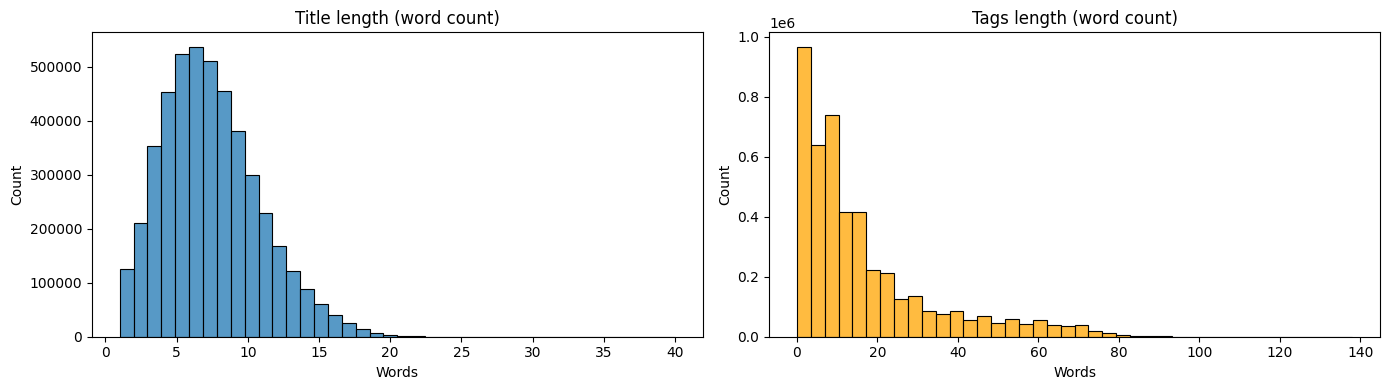

Title stats:
count    4606345.0
mean           7.1
std            3.5
min            1.0
25%            5.0
50%            7.0
75%            9.0
max           40.0
Name: title_words, dtype: float64

Tags stats:
count    4606350.0
mean          16.4
std           17.4
min            0.0
25%            4.0
50%           10.0
75%           22.0
max          138.0
Name: tags_words, dtype: float64


In [34]:

df_yt["title_words"] = df_yt["title"].dropna().str.split().str.len()
df_yt["tags_words"]  = df_yt["tags_clean"].dropna().str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_yt["title_words"].dropna(), bins=40, ax=axes[0])
axes[0].set_title("Title length (word count)")
axes[0].set_xlabel("Words")

sns.histplot(df_yt["tags_words"].dropna(), bins=40, ax=axes[1], color="orange")
axes[1].set_title("Tags length (word count)")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

print("Title stats:")
print(df_yt["title_words"].describe().round(1))
print("\nTags stats:")
print(df_yt["tags_words"].describe().round(1))

In [35]:
title_words = " ".join(df_yt["title"].dropna()).lower().split()
tags_words  = " ".join(df_yt["tags_clean"].dropna()).lower().split()

for name, words in [("Title", title_words), ("Tags", tags_words)]:
    vocab = Counter(words)
    hapax = sum(1 for w, c in vocab.items() if c == 1)
    print(f"{name}:")
    print(f"  Vocabulary size : {len(vocab):,}")
    print(f"  Words used only once  : {hapax:,} ({hapax/len(vocab):.1%})")
    print()

Title:
  Vocabulary size : 3,015,295
  Words used only once  : 1,958,002 (64.9%)

Tags:
  Vocabulary size : 3,343,048
  Words used only once  : 1,852,013 (55.4%)



### 2.3 Label Analysis

YouTube-8M-Text uses a substantially larger label vocabulary than TKGO (3,860 labels vs 101). 
All videos have at least one label assigned, with an average of 3 labels per video. 
The dominant labels (Games, Vehicle, Video game) reflect the composition of the YouTube-8M corpus, 
which over-represents gaming and automotive content relative to general web video. 
This label distribution should be kept in mind when comparing model performance across the two datasets.

In [36]:
def parse_label_names(x):
    try:
        return json.loads(x)
    except:
        return []

df_yt["labels_parsed"] = df_yt["label_names_json"].apply(parse_label_names)
df_yt["num_labels"]    = df_yt["labels_parsed"].apply(len)

with_labels_yt = df_yt["num_labels"].gt(0).sum()
print(f"Videos with labels : {with_labels_yt:,} ({with_labels_yt/len(df_yt):.2%})")
print(f"Avg labels/video   : {df_yt['num_labels'].mean():.2f}")

Videos with labels : 4,606,350 (100.00%)
Avg labels/video   : 3.03


### 2.4 TF-IDF Baseline

A TF-IDF + Logistic Regression classifier is trained on the combined title and tag text features. 
Text is preprocessed by lowercasing, removing URLs and punctuation, and combining title and tags into a single field. 
Videos with fewer than 2 tokens after cleaning are excluded. 
This mirrors the TKGO baseline setup to allow direct comparison.

In [39]:
def tags_to_text(x):
    if not isinstance(x, str):
        return ""
    try:
        tags = json.loads(x)
        if isinstance(tags, list):
            return " ".join(tags)
    except Exception:
        pass
    return ""

# Build text feature
df_yt["text"] = (
    df_yt["title"].apply(clean_text) + " " +
    df_yt["tags_json"].apply(tags_to_text).apply(clean_text)
).str.strip()

df_yt["label_ids"] = df_yt["label_ids_json"].apply(
    lambda x: json.loads(x) if isinstance(x, str) else []
)

df_yt_model = df_yt[
    df_yt["text"].str.split().apply(len) >= 2
].reset_index(drop=True)

print(f"Model-ready videos : {len(df_yt_model):,}")
print(f"Dropped (too short): {len(df_yt) - len(df_yt_model):,}")
print(f"Label space        : {df_yt['label_ids'].explode().nunique():,} unique labels")

mlb_yt = MultiLabelBinarizer()
Y_yt = mlb_yt.fit_transform(df_yt_model["label_ids"])
X_yt = df_yt_model["text"]

X_train_yt, X_test_yt, Y_train_yt, Y_test_yt = train_test_split(
    X_yt, Y_yt, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train_yt):,}  Test: {len(X_test_yt):,}")

Model-ready videos : 183,232
Dropped (too short): 41,810
Label space        : 3,862 unique labels

Train: 146,585  Test: 36,647


In [41]:
model_yt = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
    ))
])

model_yt.fit(X_train_yt, Y_train_yt)
Y_prob_yt = model_yt.predict_proba(X_test_yt)

best_yt = None
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    Y_pred = (Y_prob_yt >= t).astype(int)
    f1 = f1_score(Y_test_yt, Y_pred, average="micro", zero_division=0)
    if best_yt is None or f1 > best_yt[1]:
        best_yt = (t, f1)

Y_pred_yt = (Y_prob_yt >= best_yt[0]).astype(int)

print("TF-IDF Baseline (YouTube-8M-Text): ")
print(f"Best threshold : {best_yt[0]}")
print(f"Micro Precision: {precision_score(Y_test_yt, Y_pred_yt, average='micro', zero_division=0):.4f}")
print(f"Micro Recall   : {recall_score(Y_test_yt, Y_pred_yt, average='micro', zero_division=0):.4f}")
print(f"Micro F1       : {f1_score(Y_test_yt, Y_pred_yt, average='micro', zero_division=0):.4f}")
print(f"Macro F1       : {f1_score(Y_test_yt, Y_pred_yt, average='macro', zero_division=0):.4f}")

/Users/christosgeorghiou/anaconda3/envs/MyEnvironment1/lib/python3.12/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 3655 is present in all training examples.
  warnings.warn(
/Users/christosgeorghiou/anaconda3/envs/MyEnvironment1/lib/python3.12/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 3839 is present in all training examples.
  warnings.warn(


TF-IDF Baseline (YouTube-8M-Text): 
Best threshold : 0.5
Micro Precision: 0.3973
Micro Recall   : 0.7524
Micro F1       : 0.5200
Macro F1       : 0.3877


## 3. Dataset Comparison

The two datasets differ substantially in scale, text feature type, coverage, and label space. 
TKGO provides short-form social video data with spoken captions as the primary text signal, 
while YouTube-8M-Text provides large-scale web video data with metadata-based text features (titles and tags). 
The table below summarises the key differences relevant to this thesis.

In [43]:
# Summary comparison of both baselines
micro_f1_tkgo = f1_score(Y_test, Y_pred_tkgo, average='micro', zero_division=0)
macro_f1_tkgo = f1_score(Y_test, Y_pred_tkgo, average='macro', zero_division=0)
micro_f1_yt   = f1_score(Y_test_yt, Y_pred_yt, average='micro', zero_division=0)
macro_f1_yt   = f1_score(Y_test_yt, Y_pred_yt, average='macro', zero_division=0)

text_coverage_yt = len(df_yt_model) / len(df_yt)

print("Dataset Comparison: TKGO vs YouTube-8M-Text:\n")
print(f"{'':35s} {'TKGO':>15} {'YouTube-8M-T':>15}")
print(f"{'Videos (total)':35s} {len(df):>15,} {len(df_yt):>15,}")
print(f"{'Videos (model-ready)':35s} {len(df_tkgo_model):>15,} {len(df_yt_model):>15,}")
print(f"{'Unique labels':35s} {'101':>15} {Y_yt.shape[1]:>15,}")
print(f"{'Avg labels/video':35s} {df['num_labels'].mean():>15.2f} {df_yt['num_labels'].mean():>15.2f}")
print(f"{'Text feature':35s} {'Captions':>15} {'Title + Tags':>15}")
print(f"{'Text coverage':35s} {valid_cap.mean():>15.2%} {text_coverage_yt:>15.2%}")
print(f"{'Text type':35s} {'Speech':>15} {'Metadata':>15}")
print(f"{'-'*67}")
print(f"{'TF-IDF Micro F1':35s} {micro_f1_tkgo:>15.4f} {micro_f1_yt:>15.4f}")
print(f"{'TF-IDF Macro F1':35s} {macro_f1_tkgo:>15.4f} {macro_f1_yt:>15.4f}")

Dataset Comparison: TKGO vs YouTube-8M-Text:

                                               TKGO    YouTube-8M-T
Videos (total)                              222,552         225,042
Videos (model-ready)                         26,781         183,232
Unique labels                                   101           3,860
Avg labels/video                               1.85            3.01
Text feature                               Captions    Title + Tags
Text coverage                                16.56%          81.42%
Text type                                    Speech        Metadata
-------------------------------------------------------------------
TF-IDF Micro F1                              0.3617          0.5200
TF-IDF Macro F1                              0.2544          0.3877
